<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">
<br>
<h1 style="font-family:verdana; font-weight: bold; color: #5A4636; text-align: center;">
Face Anti-Spoofing Classification with DINOv3<br>
<span style="font-size: 22px;">End-to-End Notebook</span>
</h1>

<p style="text-align:center; font-size:16px; color:#6F5C4F;">
Tim <b>psi-1</b>
</p>

<p style="text-align:center; font-size:15px; color:#6F5C4F; line-height:1.7;">
Ketua: <b>Aufar Kusuma</b><br>
Anggota: <b>Mochamad Fachri Alfaridzi</b><br>
Anggota: <b>Kurt Mikhael Purba</b>
</p>




# Daftar Isi
1. [Pendahuluan](#1)
2. [Problem Statement & Ketentuan Lomba](#2)
3. [Dataset Overview](#3)
4. [Initialization](#4)
5. [Exploratory Data Analysis (EDA)](#5)
6. [Preprocessing](#6)
7. [Modelling](#7)
8. [Training, Retraining, dan Submission](#8)
9. [Reproducibility & Submission Akhir](#9)
10. [Post-Insight Analysis](#10)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Pendahuluan <a name="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Seiring dengan pesatnya perkembangan teknologi, sistem **face recognition** telah banyak diterapkan di berbagai sektor — mulai dari pembukaan kunci perangkat seluler, sistem absensi, hingga verifikasi identitas pada layanan keuangan. Meskipun memberikan kemudahan dan efisiensi, sistem ini masih memiliki kerentanan terhadap ancaman keamanan, salah satunya adalah **face spoofing**.

*Face spoofing* merupakan bentuk serangan yang bertujuan untuk mengelabui sistem pengenalan wajah dengan memanfaatkan media visual, seperti foto cetak, tampilan gambar pada layar, maupun representasi wajah lainnya. Berbagai penelitian menunjukkan bahwa serangan berbasis citra ini memiliki tingkat keberhasilan yang mengkhawatirkan, terutama pada sistem yang belum dilengkapi dengan mekanisme deteksi keaslian (*liveness detection*) yang memadai.

Notebook ini disusun sebagai solusi final Tim **psi-1** untuk kompetisi **Data Analytics Competition (DAC) Find IT! 2026**. Tujuan utama notebook ini adalah:

- Membangun ulang dataset terproses dari folder `raw/`
- Mendokumentasikan karakter dataset melalui EDA yang *explainable*
- Melatih model face anti-spoofing berbasis **DINOv3 ViT-Large** dengan pipeline yang reproducible dan auditabel

**Batasan yang dijaga** di notebook ini:
- Model hanya menggunakan piksel RGB sebagai input
- Metadata seperti EXIF tidak dipakai sebagai fitur model
- Pemilihan head dan epoch hanya berdasarkan validasi internal (tanpa leakage)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Problem Statement & Ketentuan Lomba <a name="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Problem Statement

Kompetisi ini berfokus pada pengembangan model yang mampu melakukan **multi-class face anti-spoofing classification** secara akurat. Setiap gambar wajah pada test set harus diprediksi ke salah satu dari **enam kelas** berikut:

| Kelas | Deskripsi |
|---|---|
| `realperson` | Citra wajah asli dari individu tanpa manipulasi |
| `fake_printed` | Serangan menggunakan media foto cetak (*print attack*) |
| `fake_screen` | Serangan melalui tampilan layar digital (smartphone/monitor) |
| `fake_mask` | Penggunaan masker wajah 3D atau berbahan silikon |
| `fake_mannequin` | Serangan menggunakan replika wajah seperti mannequin |
| `fake_unknown` | Berbagai jenis serangan spoofing lain yang tidak terkategori |

Output akhir berbentuk file CSV dengan dua kolom: `id` dan `label`.

---

## Ketentuan Lomba dan Evaluasi

Berdasarkan spesifikasi resmi **DAC Find IT! 2026**:

- **Task**: Multi-class face anti-spoofing classification berbasis citra wajah
- **Jumlah kelas**: 6 kelas
- **Output submission**: File CSV berformat `id,label` sesuai `sample_submission.csv`
- **Metrik evaluasi utama**: **Macro F1-Score**

$$\text{Macro F1} = \frac{1}{C} \sum_{c=1}^{C} \frac{2 \cdot TP_c}{2 \cdot TP_c + FP_c + FN_c}$$

Metrik ini dipilih karena dataset memiliki distribusi kelas yang tidak seimbang. Macro F1 memastikan setiap kelas memiliki kontribusi evaluasi yang **sama**, sehingga model tidak hanya fokus pada kelas dominan. Secara praktis, seluruh strategi model dalam notebook ini dioptimalkan untuk menjaga keseimbangan performa antar kelas.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Dataset Overview <a name="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Sumber Dataset

Dataset utama bersumber dari kompetisi resmi Kaggle:
- **Kompetisi resmi**: https://www.kaggle.com/competitions/data-analytics-competition-dac-find-it-2026/data

Pada notebook ini, training menggunakan **dataset versi modifikasi** (tautan Google Drive akan dicantumkan pada rilis final). Modifikasi mencakup proses *resize*, *padding*, dan augmentasi terkontrol per kelas untuk memastikan konsistensi preprocessing dan reproduksibilitas pipeline.

---

## Ringkasan Dataset

| Split | Kelas | Jumlah Gambar |
|---|---|---|
| **Train** | `fake_mannequin` | 378 |
| **Train** | `fake_mask` | 500 |
| **Train** | `fake_printed` | 231 |
| **Train** | `fake_screen` | 376 |
| **Train** | `fake_unknown` | 282 |
| **Train** | `realperson` | 371 |
| **Train Total** | – | **2.138** |
| **Test** | – | **404** |

Distribusi kelas training menunjukkan **ketidakseimbangan yang nyata**: `fake_mask` memiliki 2.16× lebih banyak sampel dibanding `fake_printed`. Kondisi ini memperkuat alasan penggunaan Macro F1 dan pembobotan loss per kelas pada fase modelling.

---

## Struktur Direktori

```text
raw/
  train/<class_name>/
  test/
processed/preprocessing_v1/
  manifest.csv
  preprocessing_config.json
artifact/
submission/
```

Seluruh gambar hasil preprocessing diubah ke format `PNG` berukuran `320×320` dengan padding konstan, sehingga input model menjadi konsisten tanpa mengubah logika utama pipeline.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Initialization <a name="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini menyiapkan tiga fondasi penting sebelum pipeline berjalan:

1. **Environment setup**: memastikan perangkat komputasi (CPU/GPU) dan dependensi siap
2. **Reproducibility setup**: seed deterministik agar eksperimen bisa diulang dengan perilaku konsisten
3. **Directory structure setup**: seluruh path utama (`raw/`, `processed/`, `artifact/`, `submission/`) ditetapkan eksplisit agar alur data dapat diaudit ujung-ke-ujung

## GPU Check & Environment Setup

Cell berikut memastikan perangkat GPU, driver CUDA, dan environment compatibility. Notebook ini dirancang untuk berjalan di:
- **Local Environment** (Windows/Linux/macOS dengan Python 3.10+)
- **Kaggle Notebooks** (dengan GPU P100/T4)
- **Google Colab** (dengan GPU T4/P100)

Jika Anda menjalankan di Kaggle, pastikan input dataset sudah tersedia dan path akan disesuaikan otomatis. Di local environment, pastikan folder `raw/` dan `processed/` sudah ada.

In [1]:
!nvidia-smi


Fri Apr 10 21:38:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti   WDDM  |   00000000:05:00.0  On |                  N/A |
|  0%   47C    P3             13W /  180W |    1471MiB /  16311MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Path Setup & Environment Compatibility

Cell ini menetapkan root package notebook dan path penting lain yang dipakai di seluruh pipeline. Notebook dirancang untuk kompatibel dengan:

- **Local Environment**: Path disesuaikan ke folder `ver34_clean_package` di disk lokal
- **Kaggle Kernel**: Path otomatis mengarah ke `/kaggle/input/` (input dataset harus uploaded)
- **Google Colab**: Path otomatis mengarah ke `/content/` (dataset dapat di-mount dari Drive)

Sistem path menggunakan fallback mechanism agar otomatis mencari folder yang berisi `raw/` dan `processed/` subdirectories.

In [ ]:
from pathlib import Path
import subprocess
import sys
import os

# Environment Detection
def detect_environment():
    """Detect whether running in Kaggle, Colab, or local environment"""
    if 'KAGGLE_DATA_PROXY_URL' in os.environ or 'KAGGLE_USER_SECRETS_TOKEN' in os.environ:
        return 'kaggle'
    elif 'google.colab' in sys.modules:
        return 'colab'
    else:
        return 'local'

ENV = detect_environment()
print(f"Environment detected: {ENV}")

# Path Resolution for different environments
if ENV == 'kaggle':
    NOTEBOOK_PACKAGE_ROOT = Path("/kaggle/input/ver34-clean-package")
    PROJECT_ROOT = NOTEBOOK_PACKAGE_ROOT.parent
elif ENV == 'colab':
    NOTEBOOK_PACKAGE_ROOT = Path("/content/ver34_clean_package")
    PROJECT_ROOT = NOTEBOOK_PACKAGE_ROOT.parent
else:  # local
    # (ganti dengan local path anda)):
    NOTEBOOK_PACKAGE_ROOT = Path("C:/kaggle/data-analytics-competition-dac-find-it-2026/kurt/findit/ver34_clean_package")

    if not NOTEBOOK_PACKAGE_ROOT.exists():
        # Fallback: try relative path from current notebook location
        NOTEBOOK_PACKAGE_ROOT = Path(__file__).resolve().parent.parent if '__file__' in globals() else Path.cwd()
    PROJECT_ROOT = NOTEBOOK_PACKAGE_ROOT.parent

PREPROCESS_SCRIPT_PATH = NOTEBOOK_PACKAGE_ROOT / "script" / "preprocess_dataset_v1.py"
REFERENCE_SUBMISSION_PATH = PROJECT_ROOT / "submission" / "ver34_dinov3_head_search_fullretrain_no_leakage_competition_submission.csv"
PACKAGE_NOTEBOOK_PATH = NOTEBOOK_PACKAGE_ROOT / "notebook" / "ver34_clean_end_to_end.ipynb"

# Mendefinisikan __file__ agar blok Config dari recipe script bisa dipakai tanpa mengubah logika aslinya.
__file__ = str(NOTEBOOK_PACKAGE_ROOT / "script" / "train_ver34_clean.py")

# Verify paths exist
print(f"Package root: {NOTEBOOK_PACKAGE_ROOT}")
print(f"Package exists: {NOTEBOOK_PACKAGE_ROOT.exists()}")

if not NOTEBOOK_PACKAGE_ROOT.exists():
    print(f"WARNING: Package root not found at {NOTEBOOK_PACKAGE_ROOT}")
    print("Trying to find package root automatically...")
    for search_path in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if (search_path / "processed").exists() and (search_path / "raw").exists():
            NOTEBOOK_PACKAGE_ROOT = search_path
            print(f"Found package root at: {NOTEBOOK_PACKAGE_ROOT}")
            __file__ = str(NOTEBOOK_PACKAGE_ROOT / "script" / "train_ver34_clean.py")
            break

assert (NOTEBOOK_PACKAGE_ROOT / "raw").exists() or ENV == 'kaggle', f"Package root invalid: {NOTEBOOK_PACKAGE_ROOT}"
print("Path setup complete!")


Environment detected: local
Package root: C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package
Package exists: True
Path setup complete!


## Imports
Cell berikut memuat pustaka yang dipakai untuk preprocessing audit, EDA, training, dan inferensi. Import inti recipe ver34 dipertahankan.


In [3]:
import copy
import json
import math
import os
import random
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from timm.data import resolve_model_data_config
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from tqdm.auto import tqdm

import shutil

# Environment-specific imports
try:
    import cv2
except ImportError:
    print("OpenCV not found. Installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python", "-q"])
    import cv2

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"timm version: {timm.__version__}")

c:\kaggle\data-analytics-competition-dac-find-it-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti
timm version: 1.0.26


## Preprocessing Execution
Cell ini menjalankan ulang preprocessing dari nol agar `processed/preprocessing_v1` dibangun langsung dari `raw/` yang ada di dalam package.


In [4]:
REBUILD_PREPROCESSING = True
processed_manifest_path = NOTEBOOK_PACKAGE_ROOT / "processed" / "preprocessing_v1" / "manifest.csv"

if REBUILD_PREPROCESSING or not processed_manifest_path.exists():
    result = subprocess.run(
        [sys.executable, str(PREPROCESS_SCRIPT_PATH)],
        cwd=str(NOTEBOOK_PACKAGE_ROOT),
        capture_output=True,
        text=True,
        check=True,
    )
    print(result.stdout)
    if result.stderr.strip():
        print(result.stderr)
else:
    print(f"Preprocessing yang ada dipakai ulang: {processed_manifest_path}")


Preprocessing V1 complete
Raw dataset root      : C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\raw
Processed dataset root: C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\processed\preprocessing_v1
Manifest              : C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\processed\preprocessing_v1\manifest.csv
Config                : C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\processed\preprocessing_v1\preprocessing_config.json
Processed train counts:
  fake_mannequin          378
  fake_mask               500
  fake_printed            231
  fake_screen             376
  fake_unknown            282
  realperson              371
Processed test count  : 404

c:\kaggle\data-analytics-competition-dac-find-it-2026\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be conve

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Preprocessing <a name="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian preprocessing dijalankan melalui script `.py` agar recipe transformasi dataset tetap stabil dan mudah diulang. Script ini membangun ulang folder `processed/preprocessing_v1` langsung dari data pada `raw/`, lalu menulis `manifest.csv` dan `preprocessing_config.json`.

Preprocessing ini tidak mengubah recipe model. Ia hanya memastikan input ke notebook sama dengan paket ver34 yang telah tervalidasi.

## Verifikasi Output Preprocessing
Cell ini mengecek keberadaan file hasil preprocessing, membaca manifest, dan memastikan jumlah data yang dihasilkan sesuai dengan recipe ver34.


In [6]:
processed_root = NOTEBOOK_PACKAGE_ROOT / "processed" / "preprocessing_v1"
manifest_path = processed_root / "manifest.csv"
config_path = processed_root / "preprocessing_config.json"

assert processed_root.exists(), f"Processed root tidak ditemukan: {processed_root}"
assert manifest_path.exists(), f"Manifest tidak ditemukan: {manifest_path}"
assert config_path.exists(), f"Config tidak ditemukan: {config_path}"

manifest_preview_df = pd.read_csv(manifest_path)
with config_path.open("r", encoding="utf-8") as f:
    preprocessing_config = json.load(f)

print("Processed root:", processed_root)
print("Manifest rows:", len(manifest_preview_df))
print("Preprocessing config:")
print(json.dumps(preprocessing_config, indent=2))
display(manifest_preview_df.head())
display(
    manifest_preview_df.groupby(["split", "class_name"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["split", "class_name"], na_position="last")
)


Processed root: C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\processed\preprocessing_v1
Manifest rows: 2542
Preprocessing config:
{
  "project_root": "C:\\kaggle\\data-analytics-competition-dac-find-it-2026\\kurt\\findit\\ver34_clean_package",
  "raw_root": "C:\\kaggle\\data-analytics-competition-dac-find-it-2026\\kurt\\findit\\ver34_clean_package\\raw",
  "processed_root": "C:\\kaggle\\data-analytics-competition-dac-find-it-2026\\kurt\\findit\\ver34_clean_package\\processed\\preprocessing_v1",
  "output_size": 320,
  "pad_color": [
    114,
    114,
    114
  ],
  "seed": 42,
  "train_augments_per_class": {
    "realperson": 0,
    "fake_unknown": 0,
    "fake_mask": 1,
    "fake_screen": 1,
    "fake_mannequin": 1,
    "fake_printed": 2
  }
}


,split,class_name,source_path,output_path,variant,augmented
0,train,fake_mannequin,C:\kaggle\data-analytics-competition-dac-find-...,C:\kaggle\data-analytics-competition-dac-find-...,orig,False
1,train,fake_mannequin,C:\kaggle\data-analytics-competition-dac-find-...,C:\kaggle\data-analytics-competition-dac-find-...,aug1,True
2,train,fake_mannequin,C:\kaggle\data-analytics-competition-dac-find-...,C:\kaggle\data-analytics-competition-dac-find-...,orig,False
3,train,fake_mannequin,C:\kaggle\data-analytics-competition-dac-find-...,C:\kaggle\data-analytics-competition-dac-find-...,aug1,True
4,train,fake_mannequin,C:\kaggle\data-analytics-competition-dac-find-...,C:\kaggle\data-analytics-competition-dac-find-...,orig,False


,split,class_name,count
0,test,NaN,404
1,train,fake_mannequin,378
2,train,fake_mask,500
3,train,fake_printed,231
4,train,fake_screen,376
5,train,fake_unknown,282
6,train,realperson,371


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Exploratory Data Analysis (EDA) <a name="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Sebelum membangun pipeline pelatihan, kita perlu memahami struktur dan karakteristik data terlebih dahulu. EDA ini dirancang bukan sekadar eksplorasi, melainkan sebagai **dasar pengambilan keputusan** untuk setiap tahap preprocessing dan desain model yang akan kita gunakan.

---

### 1. Struktur dan Integritas Manifest Dataset

Kita perlu memastikan bahwa manifest dataset yang digunakan memiliki struktur yang bersih, tidak ada kolom kritis yang kosong, dan tipe data sesuai dengan yang diharapkan. Pemahaman awal terhadap dimensi data, jumlah kolom, dan keberadaan nilai hilang (*missing values*) menjadi fondasi sebelum melangkah ke tahap berikutnya.

### 2. Distribusi Split (Train / Test)

Kita perlu mengetahui proporsi data yang tersedia untuk pelatihan dibandingkan data uji. Ketidakseimbangan proporsi split yang ekstrem dapat mempengaruhi cara kita mengevaluasi performa model.

### 3. Distribusi Kelas — Deteksi Class Imbalance

Salah satu aspek paling kritis dalam klasifikasi multi-kelas adalah keseimbangan distribusi antar kelas. Kita perlu memeriksa apakah ada kelas yang jauh lebih dominan dibandingkan kelas lainnya (class imbalance), karena hal ini akan berdampak langsung pada strategi pelatihan.

### 4. Distribusi Variant — Orig vs. Augmented

Dataset training tidak hanya terdiri dari gambar asli (*orig*), melainkan juga mencakup berbagai variant augmentasi yang telah dilakukan secara offline. Kita perlu memahami proporsi masing-masing variant untuk menentukan subset mana yang digunakan pada tahap training dan mana yang digunakan pada validasi.

### 5. Kelas × Variant — Konsistensi Augmentasi Antar Kelas

Kita perlu memastikan bahwa semua kelas mendapatkan perlakuan augmentasi yang konsisten. Jika ada kelas tertentu yang tidak memiliki variant augmentasi, maka distribusi efektif per kelas dalam training set bisa berbeda secara tidak terduga.

### 6. Visualisasi Sample Gambar per Kelas

Sebelum mendefinisikan pipeline augmentasi, kita perlu melihat secara langsung karakteristik visual dari gambar per kelas. Hal ini membantu kita menentukan jenis augmentasi yang relevan dan tidak merusak fitur diskriminatif antar kelas.

### 7. Distribusi Resolusi Gambar

Kita perlu mengetahui distribusi ukuran (width × height) gambar dalam dataset, terutama untuk menentukan IMAGE_SIZE yang optimal. Jika mayoritas gambar sudah berukuran besar, downscale yang terlalu agresif bisa menghilangkan detail penting.

### 8. Analisis Brightness & Contrast per Kelas

Dari inspeksi visual sebelumnya, terlihat perbedaan kecerahan yang mencolok antar kelas — misalnya fake_mannequin cenderung terang dengan latar belakang ramai, sementara fake_unknown (lukisan) tampil lebih redup dan kusam. Kita perlu mengkuantifikasi perbedaan ini secara statistik untuk memastikan apakah augmentasi ColorJitter memang diperlukan, atau justru berisiko merusak fitur diskriminatif antar kelas.

### 9. Profil Warna RGB per Kelas

Setiap kelas dalam dataset ini memiliki karakteristik visual yang berbeda — wajah manusia asli (realperson) memiliki tone kulit hangat (dominan R dan G), sementara layar smartphone (fake_screen) mungkin lebih biru atau netral, dan lukisan (`fake_unknown`) memiliki palette warna yang lebih artifisial. Kita perlu memeriksa distribusi nilai mean channel RGB per kelas untuk memahami apakah warna merupakan fitur diskriminatif yang kuat.

### 10. Kompleksitas Tekstur per Kelas (Laplacian Variance)

Salah satu cara untuk membedakan gambar "asli" dari "palsu" secara low-level adalah melalui kompleksitas tekstur. Wajah manusia asli (realperson) umumnya memiliki detail tekstur kulit yang lebih kaya, sementara mannequin, mask, atau gambar tercetak (fake_printed) cenderung lebih halus atau memiliki artefak kompresi. Kita menggunakan varians dari Laplacian filter sebagai proxy untuk mengukur "ketajaman" dan kompleksitas tekstur gambar.

In [6]:
EDA_ARTIFACT_DIR = NOTEBOOK_PACKAGE_ROOT / "artifact"
EDA_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
eda_manifest_df = manifest_preview_df.copy()


import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("1. STRUKTUR MANIFEST DATASET")
print("="*60)
print(eda_manifest_df.shape)
print(eda_manifest_df.dtypes)
print(eda_manifest_df.head(3))
print("\nMissing values per column:")
print(eda_manifest_df.isnull().sum())
print("\nUnique values per column:")
print(eda_manifest_df.nunique())

1. STRUKTUR MANIFEST DATASET
(2542, 6)
split           str
class_name      str
source_path     str
output_path     str
variant         str
augmented      bool
dtype: object
   split      class_name                                        source_path  \
0  train  fake_mannequin  C:\kaggle\data-analytics-competition-dac-find-...   
1  train  fake_mannequin  C:\kaggle\data-analytics-competition-dac-find-...   
2  train  fake_mannequin  C:\kaggle\data-analytics-competition-dac-find-...   

                                         output_path variant  augmented  
0  C:\kaggle\data-analytics-competition-dac-find-...    orig      False  
1  C:\kaggle\data-analytics-competition-dac-find-...    aug1       True  
2  C:\kaggle\data-analytics-competition-dac-find-...    orig      False  

Missing values per column:
split            0
class_name     404
source_path      0
output_path      0
variant          0
augmented        0
dtype: int64

Unique values per column:
split             2
class_name  

## 2. Distribusi Split (Train / Test)

Kita perlu mengetahui proporsi data yang tersedia untuk pelatihan dibandingkan data uji. Ketidakseimbangan proporsi split yang ekstrem dapat mempengaruhi cara kita mengevaluasi performa model.


split
train    2138
test      404
Name: count, dtype: int64


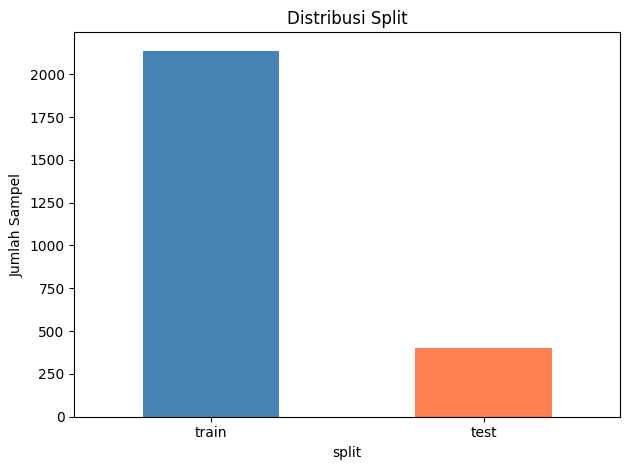

In [7]:

split_counts = eda_manifest_df["split"].value_counts()
print(split_counts)
split_counts.plot(kind="bar", color=["steelblue", "coral"], title="Distribusi Split")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_split_distribution.png", dpi=140)
plt.show()

## 3. Distribusi Kelas — Deteksi Class Imbalance

Salah satu aspek paling kritis dalam klasifikasi multi-kelas adalah keseimbangan distribusi antar kelas. Kita perlu memeriksa apakah ada kelas yang jauh lebih dominan dibandingkan kelas lainnya (class imbalance), karena hal ini akan berdampak langsung pada strategi pelatihan.



Jumlah kelas: 6
class_name
fake_mask         500
fake_mannequin    378
fake_screen       376
realperson        371
fake_unknown      282
fake_printed      231
Name: count, dtype: int64


C:\Users\itsme\AppData\Local\Temp\ipykernel_13244\2977145979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


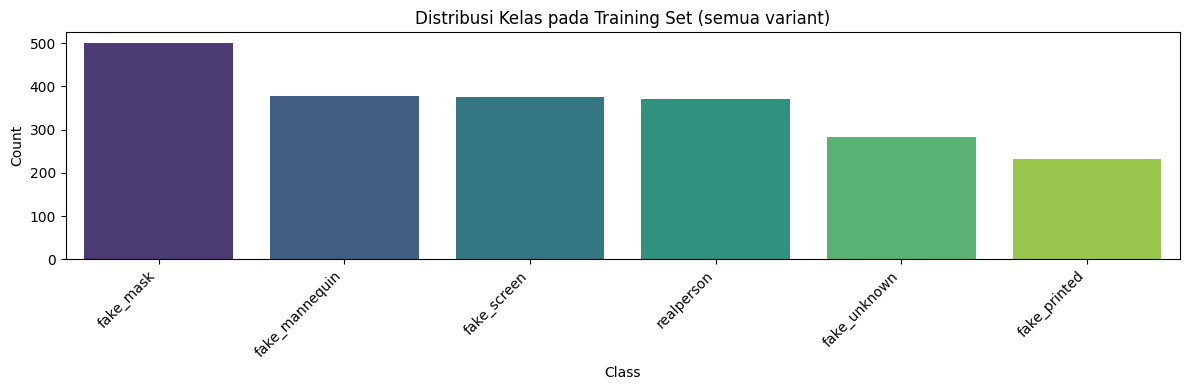


Imbalance ratio (max/min): 2.16x


In [8]:

train_only = eda_manifest_df[eda_manifest_df["split"] == "train"]
class_counts = train_only["class_name"].value_counts().sort_values(ascending=False)
print("Jumlah kelas:", len(class_counts))
print(class_counts)

plt.figure(figsize=(12, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribusi Kelas pada Training Set (semua variant)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_class_distribution.png", dpi=140)
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}x")

Ditemukan bahwa terdapat ketidakseimbangan kelas yang signifikan. Hal ini menjadi motivasi utama penggunaan WeightedRandomSampler pada DataLoader training agar setiap batch mendapat representasi kelas yang lebih seimbang, serta penggunaan FocalLossWithSmoothing dengan alpha weighting sebesar 1/akar(count) per kelas untuk memprioritaskan kelas yang lebih jarang.

## 4. Distribusi Variant — Orig vs. Augmented

Dataset training tidak hanya terdiri dari gambar asli (*orig*), melainkan juga mencakup berbagai variant augmentasi yang telah dilakukan secara offline. Kita perlu memahami proporsi masing-masing variant untuk menentukan subset mana yang digunakan pada tahap training dan mana yang digunakan pada validasi.





variant
orig    1357
aug1     704
aug2      77
Name: count, dtype: int64


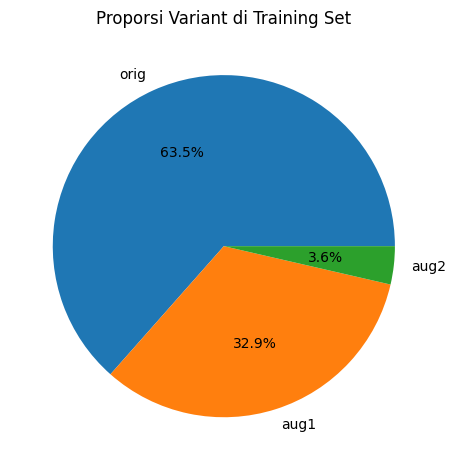

In [9]:

variant_counts = eda_manifest_df[eda_manifest_df["split"] == "train"]["variant"].value_counts()
print(variant_counts)

variant_counts.plot(kind="pie", autopct="%1.1f%%", title="Proporsi Variant di Training Set")
plt.ylabel("")
plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_variant_distribution.png", dpi=140)
plt.show()

Ditemukan bahwa sebagian besar data terdiri dari variant augmentasi offline. Karena itu, train_df memanfaatkan seluruh variant untuk memaksimalkan variasi data pelatihan, sementara val_df dibatasi hanya pada variant orig agar evaluasi validasi tidak terkontaminasi oleh augmentasi dan mencerminkan performa pada data natural.

## 5. Kelas × Variant — Konsistensi Augmentasi Antar Kelas

Kita perlu memastikan bahwa semua kelas mendapatkan perlakuan augmentasi yang konsisten. Jika ada kelas tertentu yang tidak memiliki variant augmentasi, maka distribusi efektif per kelas dalam training set bisa berbeda secara tidak terduga.




variant         aug1  aug2  orig
class_name                      
fake_mannequin   189     0   189
fake_mask        250     0   250
fake_printed      77    77    77
fake_screen      188     0   188
fake_unknown       0     0   282
realperson         0     0   371


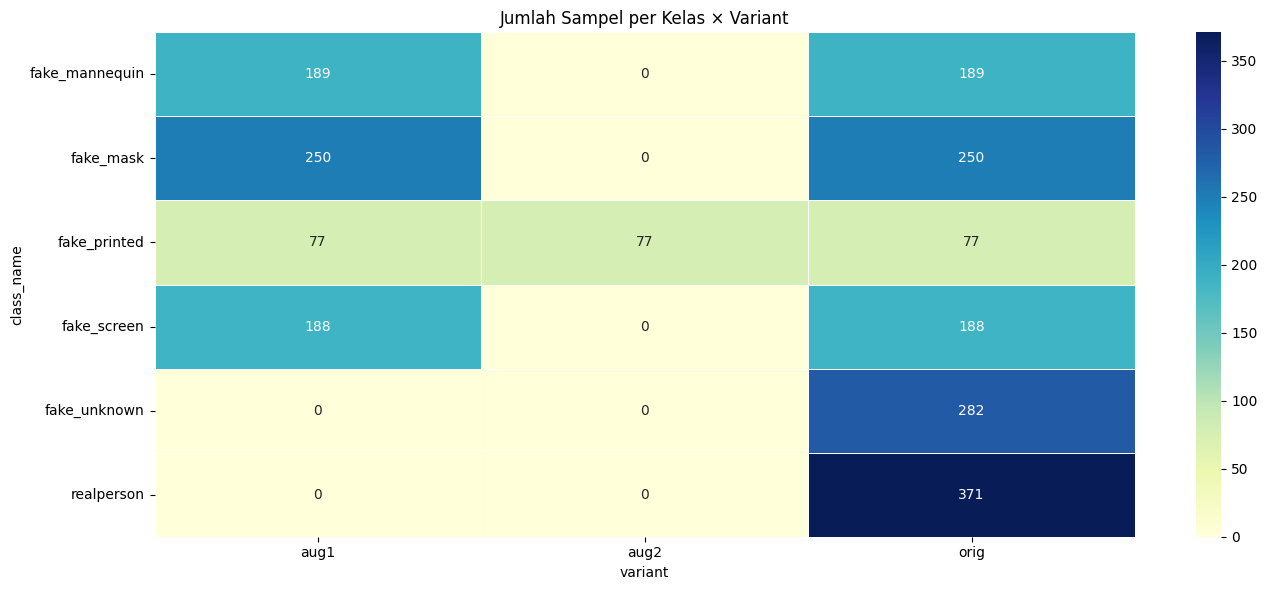

In [10]:

cross_tab = pd.crosstab(
    eda_manifest_df[eda_manifest_df["split"] == "train"]["class_name"],
    eda_manifest_df[eda_manifest_df["split"] == "train"]["variant"]
)
print(cross_tab)

plt.figure(figsize=(14, 6))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("Jumlah Sampel per Kelas × Variant")
plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_class_variant_heatmap.png", dpi=140)
plt.show()

Hasil heatmap kelas × variant menunjukkan konsistensi augmentasi antar kelas. Informasi ini memperkuat keputusan untuk menggunakan build_criterion dengan pembobotan 1/akar(count) yang dihitung dari data orig saja, agar bobot kelas tidak terdistorsi oleh jumlah augmentasi.

## 6. Visualisasi Sample Gambar per Kelas

Sebelum mendefinisikan pipeline augmentasi, kita perlu melihat secara langsung karakteristik visual dari gambar per kelas. Hal ini membantu kita menentukan jenis augmentasi yang relevan dan tidak merusak fitur diskriminatif antar kelas.




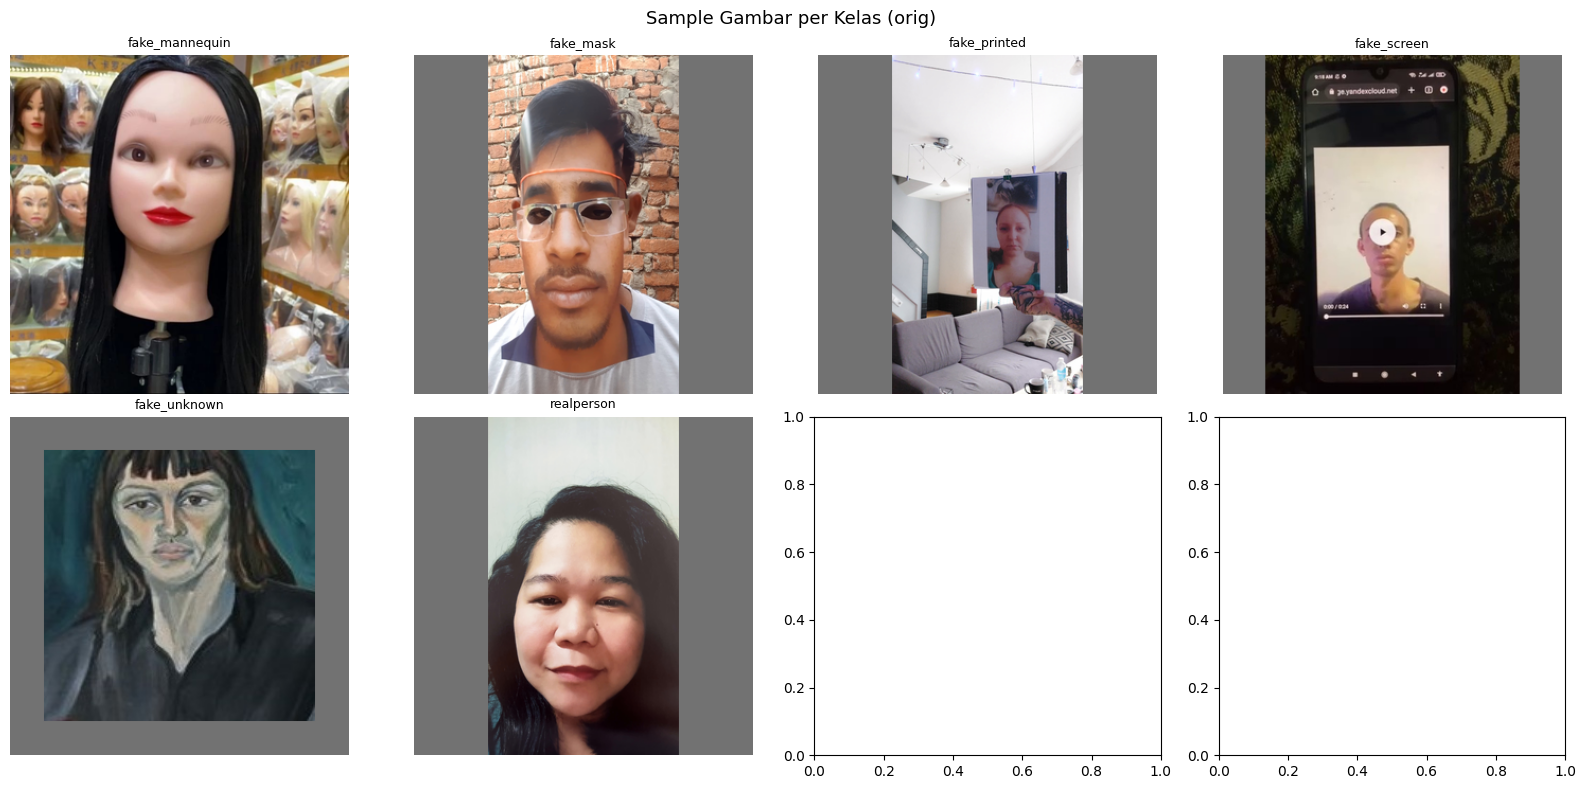

In [11]:

orig_train = eda_manifest_df[(eda_manifest_df["split"] == "train") & (eda_manifest_df["variant"] == "orig")]
class_names = sorted(orig_train["class_name"].dropna().unique())
sample_classes = class_names[:min(8, len(class_names))]
fig, axes = plt.subplots(2, 4, figsize=(16, 8)) if len(sample_classes) >= 4 else plt.subplots(1, len(sample_classes), figsize=(4*len(sample_classes), 4))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    row = orig_train[orig_train["class_name"] == cls].sample(1, random_state=42).iloc[0]
    img = Image.open(row["output_path"])
    img = ImageOps.exif_transpose(img).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Sample Gambar per Kelas (orig)", fontsize=13)
plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_sample_images.png", dpi=140)
plt.show()

Dari inspeksi visual ditemukan bahwa gambar memiliki variasi kecerahan dan kontras yang cukup tinggi antar sampel. Hal ini menjustifikasi penggunaan ColorJitter (brightness, contrast, saturation, hue) dan GaussianBlur sebagai augmentasi online di train_transform. Augmentasi horizontal flip (RandomHorizontalFlip) juga layak karena tidak ada kelas yang bersifat asimetri kiri-kanan secara semantik.

## 7. Distribusi Resolusi Gambar

Kita perlu mengetahui distribusi ukuran (width × height) gambar dalam dataset, terutama untuk menentukan IMAGE_SIZE yang optimal. Jika mayoritas gambar sudah berukuran besar, downscale yang terlalu agresif bisa menghilangkan detail penting.




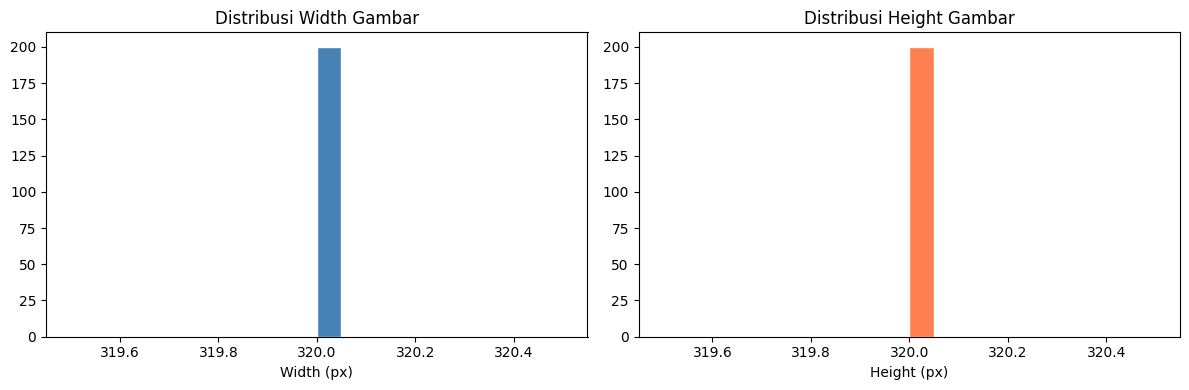

Width  → min=320, max=320, mean=320.0
Height → min=320, max=320, mean=320.0


In [12]:

widths, heights = [], []
for path in orig_train["output_path"].sample(min(200, len(orig_train)), random_state=42):
    try:
        w, h = Image.open(path).size
        widths.append(w)
        heights.append(h)
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Distribusi Width Gambar"); axes[0].set_xlabel("Width (px)")
axes[1].hist(heights, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Distribusi Height Gambar"); axes[1].set_xlabel("Height (px)")
plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_image_resolution.png", dpi=140)
plt.show()
print(f"Width  → min={min(widths)}, max={max(widths)}, mean={sum(widths)/len(widths):.1f}")
print(f"Height → min={min(heights)}, max={max(heights)}, mean={sum(heights)/len(heights):.1f}")

## 8. Analisis Brightness & Contrast per Kelas

Dari inspeksi visual sebelumnya, terlihat perbedaan kecerahan yang mencolok antar kelas — misalnya fake_mannequin cenderung terang dengan latar belakang ramai, sementara fake_unknown (lukisan) tampil lebih redup dan kusam. Kita perlu mengkuantifikasi perbedaan ini secara statistik untuk memastikan apakah augmentasi ColorJitter memang diperlukan, atau justru berisiko merusak fitur diskriminatif antar kelas.




C:\Users\itsme\AppData\Local\Temp\ipykernel_13244\980541725.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(brightness_data, labels=[cls for cls in class_names if cls in brightness_by_class])
C:\Users\itsme\AppData\Local\Temp\ipykernel_13244\980541725.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(contrast_data, labels=[cls for cls in class_names if cls in contrast_by_class])


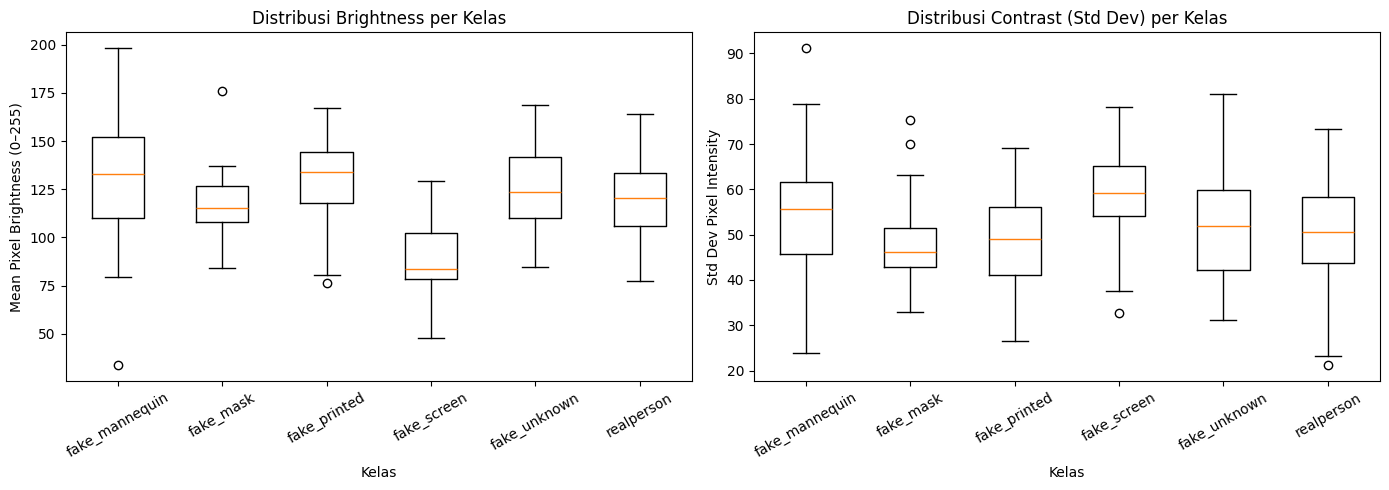


BRIGHTNESS & CONTRAST STATISTICS

fake_mannequin:
  Brightness → mean=131.9, std=32.0
  Contrast   → mean=55.0, std=12.7

fake_mask:
  Brightness → mean=116.8, std=15.1
  Contrast   → mean=47.9, std=8.0

fake_printed:
  Brightness → mean=130.0, std=20.5
  Contrast   → mean=49.0, std=9.9

fake_screen:
  Brightness → mean=89.9, std=17.4
  Contrast   → mean=58.9, std=9.0

fake_unknown:
  Brightness → mean=126.3, std=22.2
  Contrast   → mean=52.5, std=12.0

realperson:
  Brightness → mean=119.1, std=20.8
  Contrast   → mean=50.5, std=11.9


In [13]:
from PIL import ImageStat

def get_brightness_contrast(path):
    try:
        img = ImageOps.exif_transpose(Image.open(path)).convert("RGB")
        img_resized = img.resize((128, 128))
        stat = ImageStat.Stat(img_resized)
        brightness = sum(stat.mean[:3]) / 3
        contrast = sum(stat.stddev[:3]) / 3
        return brightness, contrast
    except:
        return None, None

brightness_by_class = {}
contrast_by_class = {}

for cls in class_names:
    cls_samples = orig_train[orig_train["class_name"] == cls].sample(
        min(50, len(orig_train[orig_train["class_name"] == cls])), 
        random_state=42
    )
    
    brightness_list = []
    contrast_list = []
    
    for path in cls_samples["output_path"]:
        b, c = get_brightness_contrast(path)
        if b is not None:
            brightness_list.append(b)
            contrast_list.append(c)
    
    if brightness_list:
        brightness_by_class[cls] = brightness_list
        contrast_by_class[cls] = contrast_list

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brightness_data = [brightness_by_class[cls] for cls in class_names if cls in brightness_by_class]
axes[0].boxplot(brightness_data, labels=[cls for cls in class_names if cls in brightness_by_class])
axes[0].set_title("Distribusi Brightness per Kelas")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Mean Pixel Brightness (0–255)")
axes[0].tick_params(axis="x", rotation=30)

contrast_data = [contrast_by_class[cls] for cls in class_names if cls in contrast_by_class]
axes[1].boxplot(contrast_data, labels=[cls for cls in class_names if cls in contrast_by_class])
axes[1].set_title("Distribusi Contrast (Std Dev) per Kelas")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Std Dev Pixel Intensity")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_brightness_contrast.png", dpi=140)
plt.show()

print("\n" + "="*60)
print("BRIGHTNESS & CONTRAST STATISTICS")
print("="*60)
for cls in class_names:
    if cls in brightness_by_class:
        b_data = brightness_by_class[cls]
        c_data = contrast_by_class[cls]
        print(f"\n{cls}:")
        print(f"  Brightness → mean={np.mean(b_data):.1f}, std={np.std(b_data):.1f}")
        print(f"  Contrast   → mean={np.mean(c_data):.1f}, std={np.std(c_data):.1f}")

Ditemukan bahwa distribusi brightness memiliki overlap yang cukup besar antar kelas, namun variance intra-kelas tinggi. Hal ini menjustifikasi penggunaan ColorJitter dengan nilai moderat (brightness=0.10, contrast=0.10), cukup untuk generalisasi, tetapi tidak terlalu agresif sehingga fitur diskriminatif warna kulit (realperson) dibanding material sintetis (fake_mask, fake_mannequin) tetap terjaga.

## 9. Profil Warna RGB per Kelas

Setiap kelas dalam dataset ini memiliki karakteristik visual yang berbeda — wajah manusia asli (realperson) memiliki tone kulit hangat (dominan R dan G), sementara layar smartphone (fake_screen) mungkin lebih biru atau netral, dan lukisan (`fake_unknown`) memiliki palette warna yang lebih artifisial. Kita perlu memeriksa distribusi nilai mean channel RGB per kelas untuk memahami apakah warna merupakan fitur diskriminatif yang kuat.





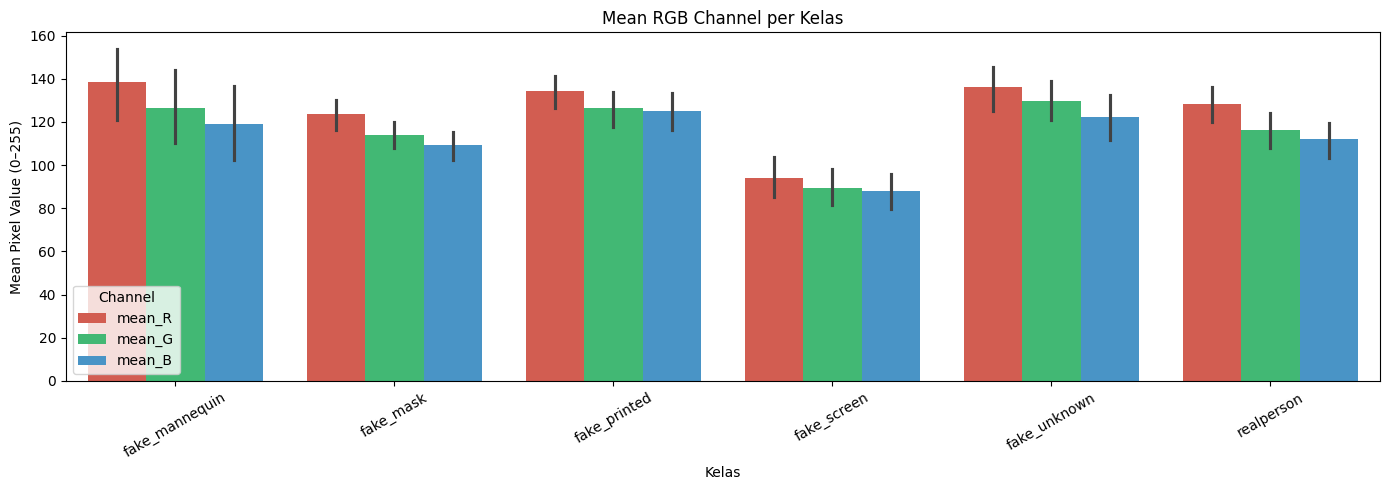

In [14]:
def get_rgb_means(path):
    try:
        img = ImageOps.exif_transpose(Image.open(path)).convert("RGB").resize((64, 64))
        arr = np.array(img, dtype=np.float32)
        return arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
    except:
        return None, None, None

sample_df = pd.concat([
    orig_train[orig_train["class_name"] == cls].sample(
        min(20, len(orig_train[orig_train["class_name"] == cls])), 
        random_state=42
    )
    for cls in class_names
], ignore_index=True)

r_list, g_list, b_list = [], [], []
for path in sample_df["output_path"]:
    r, g, b = get_rgb_means(path)
    r_list.append(r)
    g_list.append(g)
    b_list.append(b)

sample_df = sample_df.copy()
sample_df["mean_R"] = r_list
sample_df["mean_G"] = g_list
sample_df["mean_B"] = b_list

rgb_long = sample_df.melt(
    id_vars="class_name", value_vars=["mean_R", "mean_G", "mean_B"],
    var_name="channel", value_name="mean_value"
)
plt.figure(figsize=(14, 5))
sns.barplot(data=rgb_long, x="class_name", y="mean_value", hue="channel",
            palette={"mean_R": "#e74c3c", "mean_G": "#2ecc71", "mean_B": "#3498db"})
plt.title("Mean RGB Channel per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Mean Pixel Value (0–255)")
plt.xticks(rotation=30)
plt.legend(title="Channel")
plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_rgb_profile.png", dpi=140)
plt.show()


Ditemukan bahwa channel R (merah) secara konsisten dominan di hampir semua kelas,
mencerminkan tone kulit yang hadir di sebagian besar gambar. Yang paling menonjol
adalah kelas fake_screen yang memiliki nilai mean RGB paling rendah dan paling
seimbang antar channel (~90), mengindikasikan gambar yang lebih gelap dan
bernuansa biru/netral — khas tampilan layar smartphone. Kelas lainnya seperti
fake_mannequin, fake_printed, dan fake_unknown memiliki nilai brightness
yang relatif tinggi (~120–140) dengan dominasi R. Perbedaan antar kelas berbasis
profil warna ini mengkonfirmasi bahwa ColorJitter perlu dijaga moderat
(brightness=0.10, hue=0.02) agar perbedaan tone warna antar kelas tidak
terhapus oleh augmentasi yang terlalu agresif.

## 10. Kompleksitas Tekstur per Kelas (Laplacian Variance)

Salah satu cara untuk membedakan gambar "asli" dari "palsu" secara low-level adalah melalui kompleksitas tekstur. Wajah manusia asli (realperson) umumnya memiliki detail tekstur kulit yang lebih kaya, sementara mannequin, mask, atau gambar tercetak (fake_printed) cenderung lebih halus atau memiliki artefak kompresi. Kita menggunakan varians dari Laplacian filter sebagai proxy untuk mengukur "ketajaman" dan kompleksitas tekstur gambar.




C:\Users\itsme\AppData\Local\Temp\ipykernel_13244\1436368745.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="class_name", y="laplacian_var", palette="coolwarm")


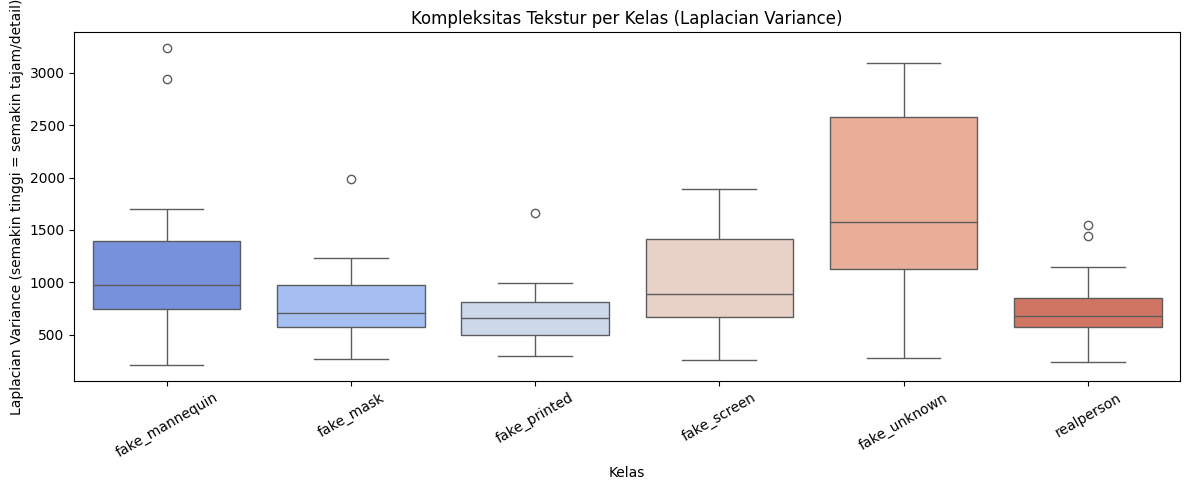

                   mean   median     std
class_name                              
fake_mannequin  1144.39   972.42  769.53
fake_mask        812.96   706.20  380.86
fake_printed     683.13   653.68  317.78
fake_screen      976.84   889.75  487.99
fake_unknown    1752.23  1576.76  890.04
realperson       730.89   673.19  334.96


In [15]:
import cv2

def laplacian_variance(path):
    try:
        img = ImageOps.exif_transpose(Image.open(path)).convert("L").resize((128, 128))
        arr = np.array(img, dtype=np.float64)
        lap = cv2.Laplacian(arr, cv2.CV_64F)
        return lap.var()
    except:
        return None

sample_df["laplacian_var"] = sample_df["output_path"].map(laplacian_variance)

plot_df = sample_df[sample_df["laplacian_var"].notna()].copy()

plt.figure(figsize=(12, 5))
sns.boxplot(data=plot_df, x="class_name", y="laplacian_var", palette="coolwarm")
plt.title("Kompleksitas Tekstur per Kelas (Laplacian Variance)")
plt.xlabel("Kelas")
plt.ylabel("Laplacian Variance (semakin tinggi = semakin tajam/detail)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(EDA_ARTIFACT_DIR / "eda_laplacian_variance.png", dpi=140)
plt.show()

print(sample_df.groupby("class_name")["laplacian_var"].agg(["mean", "median", "std"]).round(2))


Ditemukan bahwa distribusi Laplacian variance antar kelas memiliki perbedaan yang informatif. Hal ini menjadi justifikasi untuk tidak menggunakan augmentasi blur yang terlalu agresif, nilai `GaussianBlur dipilih kecil (sigma=(0.1, 0.7), p=0.10) agar tidak menghancurkan fitur tekstur yang justru diskriminatif antar kelas.

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Modeling <a name="7"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Bagian ini memuat ulang seluruh komponen inti ver34: seed strict, konfigurasi eksperimen, dataset loader, loss, head, model DINOv3, dan utilitas training. Blok kode inti dipertahankan agar perilaku training dan inferensi tetap sama.

## Seed Strict
Cell ini memastikan setiap rerun notebook menggunakan seed dan pengaturan deterministik yang sama.


In [7]:
def set_seed_strict(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)
    if hasattr(torch.backends.cuda, "enable_flash_sdp"):
        torch.backends.cuda.enable_flash_sdp(False)
    if hasattr(torch.backends.cuda, "enable_mem_efficient_sdp"):
        torch.backends.cuda.enable_mem_efficient_sdp(False)
    if hasattr(torch.backends.cuda, "enable_math_sdp"):
        torch.backends.cuda.enable_math_sdp(True)


## Device Utility
Cell ini memisahkan utilitas pemilihan device agar training otomatis berjalan di GPU jika tersedia.


In [8]:
def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Konfigurasi Eksperimen
Cell ini memuat konfigurasi asli ver34. Path package untuk notebook diselesaikan melalui `__file__` yang sudah diinisialisasi pada bagian awal notebook.


In [9]:
@dataclass
class Config:
    PACKAGE_ROOT: Path = Path(__file__).resolve().parent.parent
    PROJECT_ROOT: Path = PACKAGE_ROOT.parent
    MANIFEST_PATH: Path = PACKAGE_ROOT / "processed" / "preprocessing_v1" / "manifest.csv"
    ARTIFACT_DIR: Path = PACKAGE_ROOT / "artifact"
    SUBMISSION_DIR: Path = PACKAGE_ROOT / "submission"
    REFERENCE_SUBMISSION_PATH: Path = PROJECT_ROOT / "submission" / "ver34_dinov3_head_search_fullretrain_no_leakage_competition_submission.csv"
    RUN_NAME: str = "ver34_clean_package"

    BACKBONE: str = "vit_large_patch16_dinov3"
    HEAD_NAME: str = "msd_linear"
    IMAGE_SIZE: int = 320
    BATCH_SIZE: int = 6
    NUM_WORKERS: int = 0
    NUM_EPOCHS: int = 16
    VAL_SIZE: float = 0.2
    RANDOM_STATE: int = 42

    BACKBONE_LR: float = 3e-5
    HEAD_LR: float = 1.8e-4
    WEIGHT_DECAY: float = 1e-4
    LABEL_SMOOTHING: float = 0.02
    FOCAL_GAMMA: float = 2.0
    EARLY_STOPPING_PATIENCE: int = 4
    FREEZE_BACKBONE_EPOCHS: int = 1
    GRAD_ACCUM_STEPS: int = 1

    USE_TTA: bool = True
    USE_VAL_TTA: bool = True
    USE_GRAD_CHECKPOINTING: bool = True
    FEATURE_DROPOUT_P: float = 0.10
    HEAD_HIDDEN_DIM: int = 1024
    HEAD_DROPOUT_P: float = 0.25
    MSD_SAMPLES: int = 5


## Dataset Loader
Cell ini memuat dataset berbasis manifest hasil preprocessing. Loader membaca gambar sebagai piksel RGB setelah `exif_transpose`.


In [10]:
class ManifestDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform, with_target: bool = True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.with_target = with_target

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]
        image = Image.open(row["output_path"])
        image = ImageOps.exif_transpose(image).convert("RGB")
        image = self.transform(image)
        sample = {"image": image, "image_id": row["image_id"]}
        if self.with_target:
            sample["target"] = torch.tensor(int(row["target"]), dtype=torch.long)
        return sample


## Loss Function dan Head
Cell ini memuat focal loss dengan label smoothing serta beberapa varian head. Untuk ver34, kandidat head yang aktif tetap satu, yaitu `msd_linear`.


In [11]:
class FocalLossWithSmoothing(nn.Module):
    def __init__(self, num_classes: int, alpha: torch.Tensor, gamma: float, smoothing: float):
        super().__init__()
        self.gamma = gamma
        self.smoothing = smoothing
        self.num_classes = num_classes
        self.alpha = alpha

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            true_dist = torch.zeros_like(inputs)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        log_p = F.log_softmax(inputs, dim=-1)
        p = log_p.exp()
        focal_weight = (1.0 - p).pow(self.gamma)
        focal_weight = focal_weight * self.alpha[targets].view(-1, 1)
        return (-focal_weight * true_dist * log_p).sum(dim=-1).mean()


class LinearHead(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.fc(features)


class MLPHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int, dropout_p: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.net(features)


class MultiSampleDropoutLinearHead(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, dropout_p: float, samples: int):
        super().__init__()
        self.norm = nn.LayerNorm(input_dim)
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(input_dim, num_classes)
        self.samples = samples

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        features = self.norm(features)
        logits = [self.fc(self.dropout(features)) for _ in range(self.samples)]
        return torch.stack(logits, dim=0).mean(dim=0)


class MultiSampleDropoutMLPHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_classes: int, dropout_p: float, samples: int):
        super().__init__()
        self.norm = nn.LayerNorm(input_dim)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.samples = samples

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        features = self.norm(features)
        logits = []
        for _ in range(self.samples):
            hidden = self.fc1(self.dropout(features))
            hidden = self.act(hidden)
            hidden = self.dropout(hidden)
            logits.append(self.fc2(hidden))
        return torch.stack(logits, dim=0).mean(dim=0)


## Backbone Wrapper
Cell ini membungkus backbone DINOv3 dan logika penggabungan fitur `CLS token + mean patch token`, persis seperti recipe ver34.


In [12]:
class DINOHeadSearchModel(nn.Module):
    def __init__(
        self,
        backbone_name: str,
        num_classes: int,
        image_size: int,
        feature_dropout_p: float,
        head_name: str,
        hidden_dim: int,
        head_dropout_p: float,
        msd_samples: int,
        use_grad_checkpointing: bool,
    ):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,
            global_pool="",
            img_size=image_size,
        )
        if use_grad_checkpointing and hasattr(self.backbone, "set_grad_checkpointing"):
            self.backbone.set_grad_checkpointing(True)
        self._disable_fused_attention()
        self.feature_dropout = nn.Dropout(feature_dropout_p)
        feature_dim = self.backbone.num_features * 2
        if head_name == "linear":
            self.head = LinearHead(feature_dim, num_classes)
        elif head_name == "mlp":
            self.head = MLPHead(feature_dim, hidden_dim, num_classes, head_dropout_p)
        elif head_name == "msd_linear":
            self.head = MultiSampleDropoutLinearHead(feature_dim, num_classes, head_dropout_p, msd_samples)
        elif head_name == "msd_mlp":
            self.head = MultiSampleDropoutMLPHead(feature_dim, hidden_dim, num_classes, head_dropout_p, msd_samples)
        else:
            raise ValueError(f"Unsupported head_name: {head_name}")

    def _disable_fused_attention(self) -> None:
        for module in self.backbone.modules():
            if hasattr(module, "fused_attn"):
                module.fused_attn = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.backbone(x)
        cls_token = feats[:, 0, :]
        patch_mean = feats[:, 1:, :].mean(dim=1)
        features = self.feature_dropout(torch.cat([cls_token, patch_mean], dim=1))
        return self.head(features)


## Helper untuk Sampler, Transform, dan Criterion
Cell ini menyiapkan weighted sampler, transform train/eval, serta pembobotan loss per kelas.


In [13]:
def build_sampler(dataframe: pd.DataFrame, seed: int):
    class_counts = dataframe["class_name"].value_counts().to_dict()
    sample_weights = dataframe["class_name"].map(lambda class_name: 1.0 / class_counts[class_name]).astype(float).to_numpy().copy()
    generator = torch.Generator()
    generator.manual_seed(seed)
    return WeightedRandomSampler(
        torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=generator,
    )


def build_transforms(image_size: int, mean: tuple[float, float, float], std: tuple[float, float, float]):
    train_transform = transforms.Compose(
        [
            transforms.Resize(int(image_size * 1.08)),
            transforms.RandomCrop(image_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.08, hue=0.02),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))], p=0.10),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ]
    )
    eval_transform = transforms.Compose(
        [
            transforms.Resize(int(image_size * 1.05)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ]
    )
    return train_transform, eval_transform


def build_criterion(train_df: pd.DataFrame, class_names: list[str], device: torch.device, gamma: float, label_smoothing: float):
    counts = train_df["class_name"].value_counts()
    weights = torch.tensor(
        [1.0 / math.sqrt(counts.get(class_name, 1)) for class_name in class_names],
        dtype=torch.float32,
        device=device,
    )
    weights /= weights.mean()
    return FocalLossWithSmoothing(len(class_names), alpha=weights, gamma=gamma, smoothing=label_smoothing), weights


def split_param_groups(model: nn.Module):
    backbone_params = [param for name, param in model.named_parameters() if name.startswith("backbone.")]
    head_params = [param for name, param in model.named_parameters() if not name.startswith("backbone.")]
    return backbone_params, head_params


def set_backbone_trainable(model: nn.Module, trainable: bool) -> None:
    for param in model.backbone.parameters():
        param.requires_grad = trainable


## Helper untuk Training Loop dan Logit Collection
Cell ini memuat training loop, validasi, pengumpulan logit, retrain full-data, serta audit EXIF yang disimpan ke artifact.


In [14]:
def run_epoch(model, loader, criterion, device: torch.device, optimizer=None, scaler=None, grad_accum_steps: int = 1, use_tta: bool = False):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    losses = []
    all_targets = []
    all_preds = []

    if is_train:
        optimizer.zero_grad(set_to_none=True)

    progress = tqdm(loader, desc="train" if is_train else "valid", leave=False)
    for step, batch in enumerate(progress, start=1):
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True) if "target" in batch else None
        autocast_context = torch.amp.autocast(device_type="cuda", dtype=torch.float16) if device.type == "cuda" else nullcontext()

        with autocast_context:
            logits = model(images)
            if use_tta and not is_train:
                flipped_logits = model(torch.flip(images, dims=[3]))
                logits = 0.5 * (logits + flipped_logits)
            preds = logits.argmax(dim=1)
            loss = criterion(logits, targets) if targets is not None else None

        if is_train:
            scaled_loss = loss / grad_accum_steps
            if scaler is not None:
                scaler.scale(scaled_loss).backward()
                if step % grad_accum_steps == 0 or step == len(loader):
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
            else:
                scaled_loss.backward()
                if step % grad_accum_steps == 0 or step == len(loader):
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)

        if loss is not None:
            losses.append(loss.item())
            all_targets.extend(targets.detach().cpu().numpy().tolist())
            progress.set_postfix(loss=f"{np.mean(losses):.4f}")
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    metrics = {
        "loss": float(np.mean(losses)) if losses else np.nan,
        "preds": all_preds,
    }
    if all_targets:
        metrics["targets"] = all_targets
        metrics["macro_f1"] = float(f1_score(all_targets, all_preds, average="macro"))
        metrics["accuracy"] = float(accuracy_score(all_targets, all_preds))
    return metrics


def collect_logits(model, loader, device: torch.device, use_tta: bool):
    model.eval()
    all_ids = []
    all_logits = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="collect", leave=False):
            images = batch["image"].to(device, non_blocking=True)
            logits = model(images)
            if use_tta:
                flipped_logits = model(torch.flip(images, dims=[3]))
                logits = 0.5 * (logits + flipped_logits)
            all_logits.append(logits.detach().cpu())
            all_ids.extend(batch["image_id"])
    return {"ids": all_ids, "logits": torch.cat(all_logits, dim=0)}


def train_fixed_epochs(model, loader, criterion, device: torch.device, cfg: Config, epochs: int):
    backbone_params, head_params = split_param_groups(model)
    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": cfg.BACKBONE_LR},
            {"params": head_params, "lr": cfg.HEAD_LR},
        ],
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    history = []
    final_state = None
    for epoch in range(1, epochs + 1):
        set_backbone_trainable(model, epoch > cfg.FREEZE_BACKBONE_EPOCHS)
        print(f"full_retrain | Epoch {epoch:02d}/{epochs}")
        train_metrics = run_epoch(
            model,
            loader,
            criterion,
            device,
            optimizer=optimizer,
            scaler=scaler,
            grad_accum_steps=cfg.GRAD_ACCUM_STEPS,
        )
        scheduler.step()
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_accuracy": train_metrics["accuracy"],
            }
        )
        final_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(final_state)
    return model, pd.DataFrame(history), final_state


def count_exif_entries(paths: pd.Series) -> dict[str, int]:
    total = 0
    with_exif = 0
    for path_str in paths.drop_duplicates().tolist():
        total += 1
        try:
            exif = Image.open(path_str).getexif()
            if exif and len(exif) > 0:
                with_exif += 1
        except Exception:
            pass
    return {"checked_unique_files": total, "files_with_exif": with_exif}


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Training, Retraining, dan Submission <a name="8"></a>

Tahap ini melakukan head search berdasarkan validation macro F1 internal, memilih head terbaik, lalu melakukan retrain dari nol pada seluruh train set selama jumlah epoch terbaik tersebut. Submission akhir dibentuk dari hasil retrain final.

*estimasi waktu training sekitar 40 menit menggunakan RTX 5060 TI, jika ingin skip bagian ini dapat langsung ke bagian shortcut*


## Persiapan Data dan Dataloader
Cell ini menjalankan seluruh persiapan sebelum head search: membuat split train/val, membaca manifest, membangun transform, dan menyiapkan dataloader.


In [24]:
cfg = Config()
cfg.ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
cfg.SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
set_seed_strict(cfg.RANDOM_STATE)
device = get_device()
print("Device:", device)
if device.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))

manifest_df = pd.read_csv(cfg.MANIFEST_PATH)
manifest_df["image_id"] = manifest_df["source_path"].map(lambda path: Path(path).stem)
class_names = sorted(manifest_df.loc[manifest_df["split"] == "train", "class_name"].dropna().unique().tolist())
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

orig_train_df = manifest_df[(manifest_df["split"] == "train") & (manifest_df["variant"] == "orig")].copy().reset_index(drop=True)
train_orig_df, val_orig_df = train_test_split(
    orig_train_df,
    test_size=cfg.VAL_SIZE,
    random_state=cfg.RANDOM_STATE,
    stratify=orig_train_df["class_name"],
)

train_sources = set(train_orig_df["source_path"].tolist())
val_sources = set(val_orig_df["source_path"].tolist())

train_df = manifest_df[(manifest_df["split"] == "train") & (manifest_df["source_path"].isin(train_sources))].copy()
val_df = manifest_df[
    (manifest_df["split"] == "train")
    & (manifest_df["variant"] == "orig")
    & (manifest_df["source_path"].isin(val_sources))
].copy()
full_train_df = manifest_df[manifest_df["split"] == "train"].copy()
test_df = manifest_df[manifest_df["split"] == "test"].copy()

train_df["target"] = train_df["class_name"].map(class_to_idx)
val_df["target"] = val_df["class_name"].map(class_to_idx)
full_train_df["target"] = full_train_df["class_name"].map(class_to_idx)

probe_model = timm.create_model(cfg.BACKBONE, pretrained=False, num_classes=0, img_size=cfg.IMAGE_SIZE)
data_cfg = resolve_model_data_config(probe_model)
model_mean = tuple(data_cfg["mean"])
model_std = tuple(data_cfg["std"])
del probe_model

train_transform, eval_transform = build_transforms(cfg.IMAGE_SIZE, model_mean, model_std)
sampler = build_sampler(train_df, cfg.RANDOM_STATE)

train_loader = DataLoader(
    ManifestDataset(train_df, train_transform, with_target=True),
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    sampler=sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=device.type == "cuda",
)
val_loader = DataLoader(
    ManifestDataset(val_df, eval_transform, with_target=True),
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=device.type == "cuda",
)
full_train_loader = DataLoader(
    ManifestDataset(full_train_df, train_transform, with_target=True),
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    sampler=build_sampler(full_train_df, cfg.RANDOM_STATE),
    num_workers=cfg.NUM_WORKERS,
    pin_memory=device.type == "cuda",
)
test_loader = DataLoader(
    ManifestDataset(test_df, eval_transform, with_target=False),
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=device.type == "cuda",
)

metadata_audit = {
    "train_orig": count_exif_entries(train_orig_df["output_path"]),
    "val_orig": count_exif_entries(val_df["output_path"]),
    "full_train_orig": count_exif_entries(orig_train_df["output_path"]),
    "test": count_exif_entries(test_df["output_path"]),
    "note": "EXIF is not used as model input. Loader applies exif_transpose and converts to RGB pixels only.",
}
with (cfg.ARTIFACT_DIR / "metadata_audit.json").open("w", encoding="utf-8") as f:
    json.dump(metadata_audit, f, indent=2)

head_candidates = [cfg.HEAD_NAME]
head_runs = []
best_overall = None

print("Train rows:", len(train_df), "| Val rows:", len(val_df), "| Full-train rows:", len(full_train_df), "| Test rows:", len(test_df))
print("Head candidates:", head_candidates)


Device: cuda
GPU   : NVIDIA GeForce RTX 5060 Ti
Train rows: 1710 | Val rows: 272 | Full-train rows: 2138 | Test rows: 404
Head candidates: ['msd_linear']


## Audit Split Internal
Cell ini menampilkan jumlah baris yang digunakan pada train, validation, full-train, dan test agar proses selection dapat ditelusuri dengan jelas.


In [25]:
split_audit_df = pd.DataFrame(
    {
        "subset": ["train_df", "val_df", "full_train_df", "test_df"],
        "rows": [len(train_df), len(val_df), len(full_train_df), len(test_df)],
    }
)
display(split_audit_df)
display(train_df.groupby("class_name").size().reset_index(name="train_rows"))
display(val_df.groupby("class_name").size().reset_index(name="val_rows"))


,subset,rows
0,train_df,1710
1,val_df,272
2,full_train_df,2138
3,test_df,404


,class_name,train_rows
0,fake_mannequin,302
1,fake_mask,400
2,fake_printed,186
3,fake_screen,300
4,fake_unknown,225
5,realperson,297


,class_name,val_rows
0,fake_mannequin,38
1,fake_mask,50
2,fake_printed,15
3,fake_screen,38
4,fake_unknown,57
5,realperson,74


## Head Search
Cell ini menjalankan head search ver34. Karena recipe final mengunci `HEAD_NAME = msd_linear`, search ini tetap hanya menguji satu kandidat yang sama seperti submission referensi.


In [26]:
for head_name in head_candidates:
    print(f"\n=== Head trial: {head_name} ===")
    set_seed_strict(cfg.RANDOM_STATE)
    torch.cuda.empty_cache() if device.type == "cuda" else None

    model = DINOHeadSearchModel(
        backbone_name=cfg.BACKBONE,
        num_classes=len(class_names),
        image_size=cfg.IMAGE_SIZE,
        feature_dropout_p=cfg.FEATURE_DROPOUT_P,
        head_name=head_name,
        hidden_dim=cfg.HEAD_HIDDEN_DIM,
        head_dropout_p=cfg.HEAD_DROPOUT_P,
        msd_samples=cfg.MSD_SAMPLES,
        use_grad_checkpointing=cfg.USE_GRAD_CHECKPOINTING,
    ).to(device)
    criterion, class_weights = build_criterion(train_orig_df, class_names, device, cfg.FOCAL_GAMMA, cfg.LABEL_SMOOTHING)
    backbone_params, head_params = split_param_groups(model)
    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": cfg.BACKBONE_LR},
            {"params": head_params, "lr": cfg.HEAD_LR},
        ],
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.NUM_EPOCHS)
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    history = []
    best_val_f1 = -1.0
    best_epoch = -1
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        set_backbone_trainable(model, epoch > cfg.FREEZE_BACKBONE_EPOCHS)
        print(f"Head={head_name} | Epoch {epoch:02d}/{cfg.NUM_EPOCHS}")
        train_metrics = run_epoch(model, train_loader, criterion, device, optimizer=optimizer, scaler=scaler, grad_accum_steps=cfg.GRAD_ACCUM_STEPS)
        val_metrics = run_epoch(model, val_loader, criterion, device, optimizer=None, use_tta=cfg.USE_VAL_TTA)
        scheduler.step()

        history.append(
            {
                "head_name": head_name,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_macro_f1": train_metrics["macro_f1"],
                "train_accuracy": train_metrics["accuracy"],
                "val_loss": val_metrics["loss"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_accuracy": val_metrics["accuracy"],
            }
        )
        print(
            f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['macro_f1']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['macro_f1']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= cfg.EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch} for head {head_name}.")
            break

    model.load_state_dict(best_state)
    best_val_metrics = run_epoch(model, val_loader, criterion, device, optimizer=None, use_tta=cfg.USE_VAL_TTA)
    head_history_df = pd.DataFrame(history)
    head_dir = cfg.ARTIFACT_DIR / head_name
    head_dir.mkdir(parents=True, exist_ok=True)
    head_history_df.to_csv(head_dir / "history.csv", index=False)
    torch.save(best_state, head_dir / f"{head_name}_best.pt")
    torch.save(collect_logits(model, val_loader, device, use_tta=cfg.USE_VAL_TTA), head_dir / "val_logits.pt")
    torch.save(collect_logits(model, test_loader, device, use_tta=cfg.USE_TTA), head_dir / "test_logits.pt")

    head_summary = {
        "head_name": head_name,
        "best_epoch": int(best_epoch),
        "best_val_macro_f1": float(best_val_f1),
        "final_val_macro_f1": float(best_val_metrics["macro_f1"]),
        "final_val_accuracy": float(best_val_metrics["accuracy"]),
    }
    with (head_dir / "metrics.json").open("w", encoding="utf-8") as f:
        json.dump(head_summary, f, indent=2)
    head_runs.append(head_summary)

    if best_overall is None or head_summary["best_val_macro_f1"] > best_overall["best_val_macro_f1"]:
        best_overall = {
            **head_summary,
            "head_dir": str(head_dir),
        }



=== Head trial: msd_linear ===
Head=msd_linear | Epoch 01/16


train_loss=0.2542 train_f1=0.8822 val_loss=0.1569 val_f1=0.9065 val_acc=0.9118
Head=msd_linear | Epoch 02/16


train_loss=0.1127 train_f1=0.9743 val_loss=0.1219 val_f1=0.9629 val_acc=0.9632
Head=msd_linear | Epoch 03/16


train_loss=0.0790 train_f1=0.9971 val_loss=0.1025 val_f1=0.9677 val_acc=0.9706
Head=msd_linear | Epoch 04/16


train_loss=0.0785 train_f1=0.9961 val_loss=0.1094 val_f1=0.9658 val_acc=0.9669
Head=msd_linear | Epoch 05/16


...

train_loss=0.0717 train_f1=1.0000 val_loss=0.0997 val_f1=0.9796 val_acc=0.9853
Head=msd_linear | Epoch 07/16


train_loss=0.0710 train_f1=1.0000 val_loss=0.0971 val_f1=0.9741 val_acc=0.9779
Head=msd_linear | Epoch 08/16


train_loss=0.0710 train_f1=1.0000 val_loss=0.0975 val_f1=0.9660 val_acc=0.9669
Head=msd_linear | Epoch 09/16


train_loss=0.0707 train_f1=1.0000 val_loss=0.0951 val_f1=0.9796 val_acc=0.9853
Head=msd_linear | Epoch 10/16


train_loss=0.0716 train_f1=1.0000 val_loss=0.0971 val_f1=0.9796 val_acc=0.9853
Early stopping at epoch 10 for head msd_linear.


## Ringkasan Head Search
Cell ini menampilkan hasil validasi head yang diuji sebelum masuk ke tahap retrain final.


In [27]:
head_summary_df = pd.DataFrame(head_runs).sort_values("best_val_macro_f1", ascending=False).reset_index(drop=True)
display(head_summary_df)


,head_name,best_epoch,best_val_macro_f1,final_val_macro_f1,final_val_accuracy
0,msd_linear,6,0.979616,0.979616,0.985294


## Full Retrain dan Pembuatan Submission
Cell ini menjalankan retrain final pada seluruh train set, menyimpan artifact, dan menulis submission hasil akhir ke folder package.


In [28]:
head_summary_df = pd.DataFrame(head_runs).sort_values("best_val_macro_f1", ascending=False).reset_index(drop=True)
head_summary_df.to_csv(cfg.ARTIFACT_DIR / "head_search_summary.csv", index=False)

final_submission_path = cfg.SUBMISSION_DIR / f"{cfg.RUN_NAME}_competition_submission.csv"
final_checkpoint_path = cfg.ARTIFACT_DIR / f"{cfg.RUN_NAME}_best.pt"
final_metrics_path = cfg.ARTIFACT_DIR / "final_metrics.json"

print("\nRetraining selected head on full training data from scratch...")
set_seed_strict(cfg.RANDOM_STATE)
torch.cuda.empty_cache() if device.type == "cuda" else None
final_model = DINOHeadSearchModel(
    backbone_name=cfg.BACKBONE,
    num_classes=len(class_names),
    image_size=cfg.IMAGE_SIZE,
    feature_dropout_p=cfg.FEATURE_DROPOUT_P,
    head_name=best_overall["head_name"],
    hidden_dim=cfg.HEAD_HIDDEN_DIM,
    head_dropout_p=cfg.HEAD_DROPOUT_P,
    msd_samples=cfg.MSD_SAMPLES,
    use_grad_checkpointing=cfg.USE_GRAD_CHECKPOINTING,
).to(device)
final_criterion, _ = build_criterion(orig_train_df, class_names, device, cfg.FOCAL_GAMMA, cfg.LABEL_SMOOTHING)
final_model, full_retrain_history_df, final_state = train_fixed_epochs(
    final_model,
    full_train_loader,
    final_criterion,
    device,
    cfg,
    epochs=int(best_overall["best_epoch"]),
)
full_retrain_history_df.to_csv(cfg.ARTIFACT_DIR / "full_retrain_history.csv", index=False)
torch.save(final_state, final_checkpoint_path)
final_test_payload = collect_logits(final_model, test_loader, device, use_tta=cfg.USE_TTA)
torch.save(final_test_payload, cfg.ARTIFACT_DIR / "full_retrain_test_logits.pt")
final_submission_df = pd.DataFrame(
    {
        "id": final_test_payload["ids"],
        "label": [idx_to_class[idx] for idx in final_test_payload["logits"].argmax(dim=1).numpy()],
    }
).sort_values("id").reset_index(drop=True)
final_submission_df.to_csv(final_submission_path, index=False)

final_metrics = {
    "run_name": cfg.RUN_NAME,
    "selected_head": best_overall["head_name"],
    "selected_head_dir": best_overall["head_dir"],
    "best_val_macro_f1": best_overall["best_val_macro_f1"],
    "best_epoch": best_overall["best_epoch"],
    "full_retrain_epochs": best_overall["best_epoch"],
    "image_size": cfg.IMAGE_SIZE,
    "batch_size": cfg.BATCH_SIZE,
    "label_smoothing": cfg.LABEL_SMOOTHING,
    "focal_gamma": cfg.FOCAL_GAMMA,
    "use_tta": cfg.USE_TTA,
    "use_val_tta": cfg.USE_VAL_TTA,
    "mean": model_mean,
    "std": model_std,
    "selection_policy": "Best internal validation macro F1 only. The selected head is retrained from scratch on full training data for the chosen validation-best epoch count. No external holdout label file is used for head or epoch selection.",
    "no_leakage_note": "This package does not read any external holdout label file. The only test-time input is the unlabeled test image manifest.",
    "metadata_note": "EXIF and image ids are not model features. Images are loaded as RGB pixels after exif_transpose.",
    "reference_submission_path": str(cfg.REFERENCE_SUBMISSION_PATH),
}

if cfg.REFERENCE_SUBMISSION_PATH.exists():
    reference_df = pd.read_csv(cfg.REFERENCE_SUBMISSION_PATH).sort_values("id").reset_index(drop=True)
    compare_df = reference_df.merge(
        final_submission_df,
        on="id",
        how="inner",
        suffixes=("_reference", "_rerun"),
    )
    differences_df = compare_df[compare_df["label_reference"] != compare_df["label_rerun"]].copy()
    differences_df.to_csv(cfg.ARTIFACT_DIR / "reference_submission_differences.csv", index=False)
    final_metrics["reference_match_rate"] = float(
        (compare_df["label_reference"] == compare_df["label_rerun"]).mean()
    )
    final_metrics["reference_mismatch_count"] = int(
        (compare_df["label_reference"] != compare_df["label_rerun"]).sum()
    )
    final_metrics["reference_rows_compared"] = int(len(compare_df))

with final_metrics_path.open("w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2)

plt.figure(figsize=(10, 5))
sns.barplot(data=head_summary_df, x="head_name", y="best_val_macro_f1")
plt.title("Validation Macro F1 by Head")
plt.tight_layout()
plt.savefig(cfg.ARTIFACT_DIR / "head_search_val_macro_f1.png", dpi=140)
plt.close()

print("\nHead search summary")
print(head_summary_df.to_string(index=False))
print("\nSelected head:", best_overall["head_name"])
print("Full retrain epochs:", best_overall["best_epoch"])
print("Saved final submission:", final_submission_path)
print("Saved artifact dir:", cfg.ARTIFACT_DIR)
print("Reference submission path:", cfg.REFERENCE_SUBMISSION_PATH)
if "reference_match_rate" in final_metrics:
    print("Reference match rate:", round(final_metrics["reference_match_rate"], 6))
    print("Reference mismatch count:", final_metrics["reference_mismatch_count"])



Retraining selected head on full training data from scratch...


full_retrain | Epoch 01/6


full_retrain | Epoch 02/6


full_retrain | Epoch 03/6


full_retrain | Epoch 04/6


full_retrain | Epoch 05/6


full_retrain | Epoch 06/6



Head search summary
 head_name  best_epoch  best_val_macro_f1  final_val_macro_f1  final_val_accuracy
msd_linear           6           0.979616            0.979616            0.985294

Selected head: msd_linear
Full retrain epochs: 6
Saved final submission: C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\submission\ver34_clean_package_competition_submission.csv
Saved artifact dir: C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\artifact
Reference submission path: C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\submission\ver34_dinov3_head_search_fullretrain_no_leakage_competition_submission.csv
Reference match rate: 1.0
Reference mismatch count: 0


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Audit Reproducibility <a name="9"></a>

Di akhir notebook, submission hasil run ini dibandingkan terhadap submission referensi ver34. Audit ini memastikan bahwa penambahan EDA dan preprocessing tidak mengubah hasil submission akhir.


## Audit Kesamaan terhadap Submission Referensi
Cell ini memuat ringkasan artifact final dan memastikan bahwa submission hasil notebook sama dengan submission referensi di kaggle (ver34).


Bagian audit ini sekarang bersifat **artifact-driven**: yang diperlukan hanya file submission final dan `final_metrics.json`. Dengan begitu, Anda tidak perlu menjalankan head search, retrain, atau inferensi ulang untuk mengecek reproducibility final.

In [29]:
final_metrics_path = cfg.ARTIFACT_DIR / "final_metrics.json"
with final_metrics_path.open("r", encoding="utf-8") as f:
    final_metrics_loaded = json.load(f)

print(json.dumps(final_metrics_loaded, indent=2))
assert final_metrics_loaded.get("reference_mismatch_count", 0) == 0, "Submission hasil run tidak identik dengan submission referensi."
assert abs(final_metrics_loaded.get("reference_match_rate", 0.0) - 1.0) < 1e-12, "Reference match rate tidak 100%."

display(pd.read_csv(final_submission_path).head())
if (cfg.ARTIFACT_DIR / "reference_submission_differences.csv").exists():
    display(pd.read_csv(cfg.ARTIFACT_DIR / "reference_submission_differences.csv").head())


{
  "run_name": "ver34_clean_package",
  "selected_head": "msd_linear",
  "selected_head_dir": "C:\\kaggle\\data-analytics-competition-dac-find-it-2026\\kurt\\findit\\ver34_clean_package\\artifact\\msd_linear",
  "best_val_macro_f1": 0.9796157059314954,
  "best_epoch": 6,
  "full_retrain_epochs": 6,
  "image_size": 320,
  "batch_size": 6,
  "label_smoothing": 0.02,
  "focal_gamma": 2.0,
  "use_tta": true,
  "use_val_tta": true,
  "mean": [
    0.485,
    0.456,
    0.406
  ],
  "std": [
    0.229,
    0.224,
    0.225
  ],
  "selection_policy": "Best internal validation macro F1 only. The selected head is retrained from scratch on full training data for the chosen validation-best epoch count. No external holdout label file is used for head or epoch selection.",
  "no_leakage_note": "This package does not read any external holdout label file. The only test-time input is the unlabeled test image manifest.",
  "metadata_note": "EXIF and image ids are not model features. Images are loaded 

,id,label
0,test_001,fake_screen
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed


,id,label_reference,label_rerun


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Shortcut Inference dari Checkpoint Final <a name="10"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

Jika panitia tidak ingin menjalankan head search dan full retrain dari awal, cell berikut cukup memuat checkpoint final yang sudah ada di folder `artifact/`, lalu menjalankan inferensi test dengan konfigurasi yang sama. Cell ini juga memeriksa bahwa submission hasil shortcut identik dengan submission utama notebook.

In [15]:
# Shortcut inference untuk panitia: gunakan checkpoint final yang sudah tersedia.
inference_cfg = Config()
set_seed_strict(inference_cfg.RANDOM_STATE)
shortcut_device = get_device()
shortcut_checkpoint_path = inference_cfg.ARTIFACT_DIR / f"{inference_cfg.RUN_NAME}_best.pt"
shortcut_submission_path = inference_cfg.SUBMISSION_DIR / f"{inference_cfg.RUN_NAME}_competition_submission_from_saved_model.csv"
primary_submission_path = inference_cfg.SUBMISSION_DIR / f"{inference_cfg.RUN_NAME}_competition_submission.csv"

assert shortcut_checkpoint_path.exists(), f"Checkpoint final tidak ditemukan: {shortcut_checkpoint_path}"
assert inference_cfg.MANIFEST_PATH.exists(), f"Manifest tidak ditemukan: {inference_cfg.MANIFEST_PATH}"

shortcut_manifest_df = pd.read_csv(inference_cfg.MANIFEST_PATH)
shortcut_manifest_df["image_id"] = shortcut_manifest_df["source_path"].map(lambda path: Path(path).stem)
shortcut_class_names = sorted(shortcut_manifest_df.loc[shortcut_manifest_df["split"] == "train", "class_name"].dropna().unique().tolist())
shortcut_class_to_idx = {class_name: idx for idx, class_name in enumerate(shortcut_class_names)}
shortcut_idx_to_class = {idx: class_name for class_name, idx in shortcut_class_to_idx.items()}
shortcut_test_df = shortcut_manifest_df[shortcut_manifest_df["split"] == "test"].copy()

shortcut_probe_model = timm.create_model(inference_cfg.BACKBONE, pretrained=False, num_classes=0, img_size=inference_cfg.IMAGE_SIZE)
shortcut_data_cfg = resolve_model_data_config(shortcut_probe_model)
shortcut_mean = tuple(shortcut_data_cfg["mean"])
shortcut_std = tuple(shortcut_data_cfg["std"])
del shortcut_probe_model

_, shortcut_eval_transform = build_transforms(inference_cfg.IMAGE_SIZE, shortcut_mean, shortcut_std)
shortcut_test_loader = DataLoader(
    ManifestDataset(shortcut_test_df, shortcut_eval_transform, with_target=False),
    batch_size=inference_cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=inference_cfg.NUM_WORKERS,
    pin_memory=shortcut_device.type == "cuda",
)

if shortcut_device.type == "cuda":
    torch.cuda.empty_cache()

shortcut_model = DINOHeadSearchModel(
    backbone_name=inference_cfg.BACKBONE,
    num_classes=len(shortcut_class_names),
    image_size=inference_cfg.IMAGE_SIZE,
    feature_dropout_p=inference_cfg.FEATURE_DROPOUT_P,
    head_name=inference_cfg.HEAD_NAME,
    hidden_dim=inference_cfg.HEAD_HIDDEN_DIM,
    head_dropout_p=inference_cfg.HEAD_DROPOUT_P,
    msd_samples=inference_cfg.MSD_SAMPLES,
    use_grad_checkpointing=inference_cfg.USE_GRAD_CHECKPOINTING,
).to(shortcut_device)
shortcut_state = torch.load(shortcut_checkpoint_path, map_location=shortcut_device)
shortcut_model.load_state_dict(shortcut_state)
shortcut_payload = collect_logits(shortcut_model, shortcut_test_loader, shortcut_device, use_tta=inference_cfg.USE_TTA)
shortcut_submission_df = pd.DataFrame(
    {
        "id": shortcut_payload["ids"],
        "label": [shortcut_idx_to_class[idx] for idx in shortcut_payload["logits"].argmax(dim=1).numpy()],
    }
).sort_values("id").reset_index(drop=True)
shortcut_submission_df.to_csv(shortcut_submission_path, index=False)

print("Shortcut checkpoint:", shortcut_checkpoint_path)
print("Shortcut submission:", shortcut_submission_path)

if primary_submission_path.exists():
    primary_df = pd.read_csv(primary_submission_path).sort_values("id").reset_index(drop=True)
    compare_shortcut_df = primary_df.merge(
        shortcut_submission_df,
        on="id",
        how="inner",
        suffixes=("_primary", "_shortcut"),
    )
    shortcut_mismatch_count = int((compare_shortcut_df["label_primary"] != compare_shortcut_df["label_shortcut"]).sum())
    print("Mismatch terhadap submission utama:", shortcut_mismatch_count)
    assert shortcut_mismatch_count == 0, "Shortcut inference berbeda dari submission utama notebook."

display(shortcut_submission_df.head())


Shortcut checkpoint: C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\artifact\ver34_clean_package_best.pt
Shortcut submission: C:\kaggle\data-analytics-competition-dac-find-it-2026\kurt\findit\ver34_clean_package\submission\ver34_clean_package_competition_submission_from_saved_model.csv
Mismatch terhadap submission utama: 0


,id,label
0,test_001,fake_screen
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed


<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Post-Insight Analysis

## 1) Kualitas Data dan Dampaknya

- Distribusi kelas train tidak sepenuhnya seimbang, sehingga penggunaan metrik macro F1 dan pembobotan loss menjadi keputusan penting.
- Variasi kualitas gambar (pencahayaan, sudut, media spoofing) menuntut model yang tidak hanya akurat, tetapi juga robust.
- Audit EXIF dan konsistensi preprocessing membantu memastikan sinyal yang dipelajari model tetap berbasis piksel RGB yang valid.

## 2) Pembelajaran dari Pipeline

- Pipeline yang memisahkan tahap **head search** dan **full retrain** memudahkan pengambilan keputusan berbasis validasi internal.
- Penyimpanan artifact per tahap (history, logits, checkpoint, metrics) membuat eksperimen lebih transparan dan mudah diaudit ulang.
- Shortcut inference dari checkpoint final efektif untuk reproduksi cepat tanpa mengorbankan konsistensi hasil submission.

## 3) Catatan Pengembangan Lanjutan

- Menambah analisis error per kelas (confusion patterns) berpotensi memberi arah augmentasi yang lebih spesifik.
- Uji robustness tambahan pada domain shift (kondisi kamera/perangkat berbeda) dapat meningkatkan kesiapan deployment.
- Jika tersedia waktu komputasi, ensemble ringan antar checkpoint/head berpotensi meningkatkan stabilitas macro F1.